# EcoHome Energy Advisor - Database Setup

In this notebook, you'll set up the database for the EcoHome Energy Advisor. The database will store:
- Energy usage data (consumption, device types, costs)
- Solar generation data (production, weather conditions)
- **User preferences** - the household profile the agent uses to personalise advice (added)

## Learning Objectives
- Create SQLite database with proper schema
- Populate database with sample data
- Query data for analysis
- Understand database design for energy management

### What changed from the starter, and why
| Starter behaviour | Problem | This solution |
|---|---|---|
| Every device recorded every hour; the EV drew ~10 kWh **every hour** | ~340 kWh/day for one house, so any advice built on it is meaningless | Discrete device behaviour (charge sessions, dishwasher cycles, pool-pump runtime, temperature-driven HVAC): ~35-45 kWh/day |
| Flat $0.10 / $0.15 prices | Did not match the prices the agent quotes | Costs use the **same** time-of-use tariff as `get_electricity_prices` (`energy_model.hourly_rate`) |
| Random weather per day | Solar history unrelated to real conditions | Solar history driven by **real observed weather** for the last 30 days from Open-Meteo (deterministic mock offline) |
| Re-running appended duplicate rows | Totals doubled on every run | `reset_database()` drops and recreates the tables first |
| One commit per row (~3,000 commits) | Slow | Bulk inserts in one transaction |

The household deliberately has **un-optimised habits** (EV plugged in on arrival at ~18:00, dishwasher after dinner, pool pump running into the 16:00 peak), so the history contains real savings the agent can discover.

## 1. Import Required Libraries

In [1]:
# Import the necessary libraries
from datetime import datetime, timedelta
import random

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import inspect

import config
from models.energy import DatabaseManager
from energy_model import DEFAULT_HOUSEHOLD_PROFILE, TARIFF, tou_period
from sample_data import generate_sample_data, seed_preferences

pd.set_option("display.width", 140)
print("Solution folder:", config.PROJECT_ROOT)

Solution folder: C:\Users\tarie\source\repos\Woolf\ecohome-energy-advisor\ecohome_solution


## 2. Initialize Database Manager

In [2]:
# Create a DatabaseManager instance
# Initialize it with the path "data/energy_data.db"
# (relative paths are anchored to the solution folder, so this works from any working directory)
db_manager = DatabaseManager("data/energy_data.db")
print(db_manager.db_path)

C:\Users\tarie\source\repos\Woolf\ecohome-energy-advisor\ecohome_solution\data\energy_data.db


## 3. Create Database Tables

In [3]:
# Create the database tables
# Use the create_tables() method from your DatabaseManager
db_manager.create_tables()

# Make the notebook safely re-runnable: start from empty tables every time.
db_manager.reset_database()

inspector = inspect(db_manager.engine)
for table in inspector.get_table_names():
    cols = [f"{c['name']} ({c['type']})" for c in inspector.get_columns(table)]
    print(f"{table}:\n    " + "\n    ".join(cols))

required = {"energy_usage", "solar_generation"}  # EnergyUsage and SolarGeneration models
assert required <= set(inspector.get_table_names()), "required tables missing"
print("\nRequired tables present:", sorted(required))

Database tables created at C:\Users\tarie\source\repos\Woolf\ecohome-energy-advisor\ecohome_solution\data\energy_data.db


energy_usage:
    id (INTEGER)
    timestamp (DATETIME)
    consumption_kwh (FLOAT)
    device_type (VARCHAR(50))
    device_name (VARCHAR(100))
    cost_usd (FLOAT)
solar_generation:
    id (INTEGER)
    timestamp (DATETIME)
    generation_kwh (FLOAT)
    weather_condition (VARCHAR(50))
    temperature_c (FLOAT)
    solar_irradiance (FLOAT)
user_preferences:
    id (INTEGER)
    key (VARCHAR(100))
    value_json (TEXT)
    category (VARCHAR(50))
    source (VARCHAR(50))
    updated_at (DATETIME)

Required tables present: ['energy_usage', 'solar_generation']


## 4. Generate Sample Energy Usage Data

`sample_data.generate_sample_data()` simulates 30 full days plus today (up to the current hour).

| Device type | Device | Behaviour modelled |
|---|---|---|
| `EV` | Tesla Model 3 | ~35 mi/day at 0.25 kWh/mi; charges at 7.4 kW when ~18+ kWh is owed. 65% of sessions start on arrival (17-19h, on-peak), the rest at 23:00; some weekend midday top-ups |
| `HVAC` | Main Heat Pump | Cooling when outdoor temperature > 24 °C in occupied afternoon/evening hours; heating below 13 °C |
| `appliance` | Dishwasher / Washing Machine / Dryer | Dishwasher most evenings 19-22h; laundry Tue/Thu evenings and weekend mornings |
| `pool_pump` | Variable-Speed Pool Pump | 1.1 kW, 12:00-18:00 daily (two hours inside the peak) |
| `water_heater` | Heat Pump Water Heater | Morning and evening recovery |
| `base_load` | Fridge, lighting & electronics | Always-on load, higher in the evening |

Costs are `kWh x effective_rate` from the tariff below, the same one `get_electricity_prices` returns.

In [4]:
print(TARIFF["name"])
display(pd.DataFrame(TARIFF["periods"]).T)

# Generate data for the past 30 days (seeded, so it is reproducible)
data = generate_sample_data(days=30, seed=42)
print(f"Weather used for the history: {data['weather_source']}")

usage_rows = data["usage"]
records_created = db_manager.bulk_add_usage(usage_rows)
print(f"Created {records_created} energy usage records "
      f"({data['start']:%Y-%m-%d} -> {data['end']:%Y-%m-%d %H:%M})")
pd.DataFrame(usage_rows[:8])

EcoHome Mock TOU-EV (modelled on California residential time-of-use plans)


,rate,demand_charge,window
off_peak,0.22,0.0,22:00-07:00
mid_peak,0.32,0.02,"07:00-10:00, 15:00-16:00, 21:00-22:00"
solar_midday,0.24,0.0,10:00-15:00
on_peak,0.48,0.05,16:00-21:00 (weekdays)
critical_peak,0.96,0.1,16:00-21:00 on event days


Weather used for the history: open-meteo.com (observed/analysis)


Created 1253 energy usage records (2026-08-27 -> 2026-09-26 11:55)


,timestamp,consumption_kwh,device_type,device_name,cost_usd
0,2026-08-27 00:00:00,0.334,base_load,"Fridge, lighting & electronics",0.0715
1,2026-08-27 01:00:00,0.324,base_load,"Fridge, lighting & electronics",0.0693
2,2026-08-27 02:00:00,0.293,base_load,"Fridge, lighting & electronics",0.0627
3,2026-08-27 03:00:00,0.329,base_load,"Fridge, lighting & electronics",0.0702
4,2026-08-27 04:00:00,0.350,base_load,"Fridge, lighting & electronics",0.0748
5,2026-08-27 05:00:00,0.273,base_load,"Fridge, lighting & electronics",0.0583
6,2026-08-27 06:00:00,0.491,base_load,"Fridge, lighting & electronics",0.1050
7,2026-08-27 07:00:00,0.477,base_load,"Fridge, lighting & electronics",0.1578


## 5. Generate Sample Solar Generation Data

Solar output uses the same PV model as the forecast tool: a 7.2 kW array, 0.86 system derate and a
-0.4 %/°C cell-temperature loss, fed with hourly shortwave irradiance. When online, the irradiance and
temperature are **real observations for San Francisco over the last 30 days** from Open-Meteo.

In [5]:
generation_rows = data["generation"]
generation_records = db_manager.bulk_add_generation(generation_rows)
print(f"Created {generation_records} solar generation records")
pd.DataFrame(generation_rows[:8])

Created 405 solar generation records


,timestamp,generation_kwh,weather_condition,temperature_c,solar_irradiance
0,2026-08-27 06:00:00,0.050,partly_cloudy,13.9,8.3
1,2026-08-27 07:00:00,0.714,sunny,14.3,121.8
2,2026-08-27 08:00:00,1.905,sunny,16.7,317.3
3,2026-08-27 09:00:00,2.981,sunny,18.6,516.3
4,2026-08-27 10:00:00,4.005,sunny,20.7,685.3
5,2026-08-27 11:00:00,4.609,sunny,22.8,813.3
6,2026-08-27 12:00:00,5.035,sunny,23.7,885.8
7,2026-08-27 13:00:00,4.746,sunny,24.2,895.0


## 5b. Seed the Household Profile (personalisation)

The agent reads this table on every question (and can update it when the user states a preference),
so advice uses the real array size, EV departure time and comfort range instead of generic defaults.

In [6]:
n = seed_preferences(db_manager)
print(f"Stored {n} preferences")
pd.Series(db_manager.get_preferences(), name="value").to_frame()

Stored 26 preferences


,value
battery_capacity_kwh,13.5
battery_power_kw,5.0
comfort_cooling_setpoint_f,76
comfort_heating_setpoint_f,68
comfort_max_f,78
comfort_min_f,66
dishwasher_kwh_per_cycle,1.2
dryer_kwh_per_cycle,3.0
ev_battery_kwh,75.0
ev_charger_kw,7.7


## 6. Query and Analyze Data

In [7]:
# Query the data to verify it was inserted correctly
print("Row counts:", db_manager.table_counts())

# Get recent data for analysis
recent_usage = db_manager.get_recent_usage(24)  # Last 24 hours
recent_generation = db_manager.get_recent_generation(24)

print("=== Energy Usage Analysis ===")
print(f"Total records in last 24 hours: {len(recent_usage)}")

# Group by device type
device_consumption = {}
for record in recent_usage:
    device = record.device_type or 'unknown'
    if device not in device_consumption:
        device_consumption[device] = {'kwh': 0, 'cost': 0, 'records': 0}
    device_consumption[device]['kwh'] += record.consumption_kwh
    device_consumption[device]['cost'] += record.cost_usd or 0
    device_consumption[device]['records'] += 1

print("\nConsumption by device type:")
for device, d in sorted(device_consumption.items(), key=lambda kv: -kv[1]['kwh']):
    print(f"  {device}: {d['kwh']:.2f} kWh, ${d['cost']:.2f}, {d['records']} records")

print(f"\n=== Solar Generation Analysis ===")
print(f"Total generation records in last 24 hours: {len(recent_generation)}")
total_generation = sum(r.generation_kwh for r in recent_generation)
print(f"Total generation: {total_generation:.2f} kWh")

# Weather breakdown
weather_breakdown = {}
for record in recent_generation:
    weather = record.weather_condition or 'unknown'
    weather_breakdown.setdefault(weather, {'kwh': 0, 'records': 0})
    weather_breakdown[weather]['kwh'] += record.generation_kwh
    weather_breakdown[weather]['records'] += 1

print("\nGeneration by weather condition:")
for weather, d in weather_breakdown.items():
    print(f"  {weather}: {d['kwh']:.2f} kWh, {d['records']} records")

Row counts: {'energy_usage': 1253, 'solar_generation': 405, 'user_preferences': 26}
=== Energy Usage Analysis ===
Total records in last 24 hours: 47

Consumption by device type:
  EV: 24.97 kWh, $13.07, 4 records
  base_load: 12.25 kWh, $4.37, 24 records
  pool_pump: 6.44 kWh, $2.34, 6 records
  appliance: 4.42 kWh, $1.36, 4 records
  water_heater: 2.42 kWh, $0.95, 6 records
  HVAC: 2.36 kWh, $0.69, 3 records

=== Solar Generation Analysis ===
Total generation records in last 24 hours: 12
Total generation: 30.33 kWh

Generation by weather condition:
  sunny: 16.03 kWh, 5 records
  partly_cloudy: 6.08 kWh, 3 records
  cloudy: 8.22 kWh, 4 records


In [8]:
# Whole-period statistics with pandas
usage_df = pd.DataFrame(usage_rows)
usage_df["date"] = usage_df["timestamp"].dt.date
usage_df["hour"] = usage_df["timestamp"].dt.hour
usage_df["period"] = [tou_period(t.hour, t.date()) for t in usage_df["timestamp"]]
gen_df = pd.DataFrame(generation_rows)
gen_df["date"] = gen_df["timestamp"].dt.date
gen_df["hour"] = gen_df["timestamp"].dt.hour

full_days = usage_df["date"].nunique() - 1  # today is partial
by_device = (usage_df[usage_df["date"] < datetime.now().date()]
             .groupby("device_type")[["consumption_kwh", "cost_usd"]].sum()
             .assign(kwh_per_day=lambda d: d.consumption_kwh / full_days,
                     cost_per_day=lambda d: d.cost_usd / full_days,
                     share_pct=lambda d: 100 * d.consumption_kwh / d.consumption_kwh.sum())
             .sort_values("cost_usd", ascending=False).round(2))
display(by_device)

daily = pd.DataFrame({
    "consumption_kwh": usage_df.groupby("date")["consumption_kwh"].sum(),
    "solar_kwh": gen_df.groupby("date")["generation_kwh"].sum(),
    "cost_usd": usage_df.groupby("date")["cost_usd"].sum(),
    "weather": gen_df.groupby("date")["weather_condition"].agg(lambda s: s.mode().iat[0]),
}).round(2)
print(f"Average daily consumption: {daily.consumption_kwh[:-1].mean():.1f} kWh | "
      f"average daily solar: {daily.solar_kwh[:-1].mean():.1f} kWh | "
      f"average daily gross cost: ${daily.cost_usd[:-1].mean():.2f}")
daily.tail(10)

,consumption_kwh,cost_usd,kwh_per_day,cost_per_day,share_pct
device_type,,,,,
base_load,359.99,125.30,12.00,4.18,35.41
EV,264.00,99.28,8.80,3.31,25.97
pool_pump,198.04,70.24,6.60,2.34,19.48
appliance,88.08,37.98,2.94,1.27,8.66
water_heater,75.20,29.37,2.51,0.98,7.40
HVAC,31.31,13.69,1.04,0.46,3.08


Average daily consumption: 33.9 kWh | average daily solar: 28.9 kWh | average daily gross cost: $12.53


,consumption_kwh,solar_kwh,cost_usd,weather
date,,,,
2026-09-17,25.08,18.23,9.60,cloudy
2026-09-18,22.76,27.93,8.32,sunny
2026-09-19,50.00,28.83,15.06,sunny
2026-09-20,25.80,13.05,7.52,cloudy
2026-09-21,22.43,16.38,11.72,cloudy
2026-09-22,55.12,21.11,24.57,cloudy
2026-09-23,22.79,29.36,8.47,sunny
2026-09-24,25.51,31.70,9.52,sunny
2026-09-25,47.35,30.95,21.37,sunny


## 6b. Visualise the Patterns

Three views the agent's advice is built on: *when* energy is used versus when the sun shines and prices peak,
day-by-day balance, and where the money goes by time-of-use period.

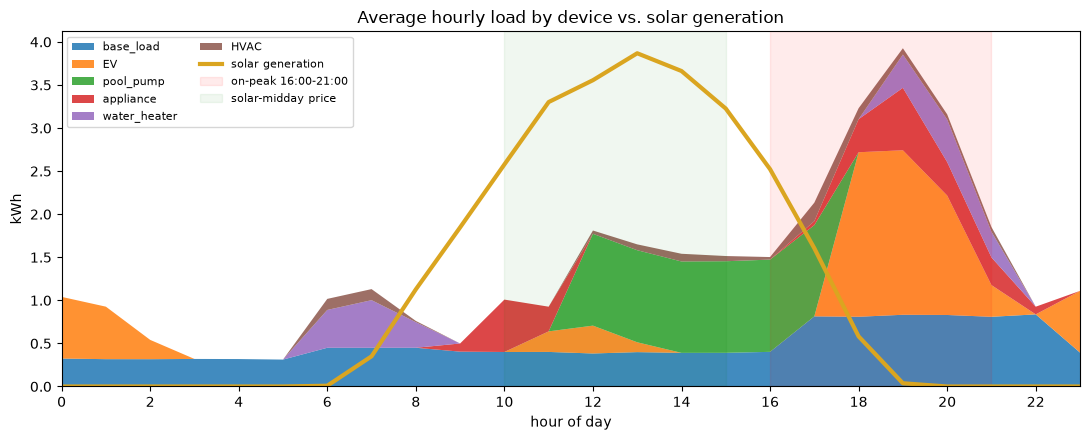

In [9]:
figdir = config.REPORTS_DIR / "figures"
figdir.mkdir(parents=True, exist_ok=True)

profile = (usage_df.groupby(["hour", "device_type"])["consumption_kwh"].sum().unstack(fill_value=0) / (full_days + 1))
solar_profile = gen_df.groupby("hour")["generation_kwh"].sum().reindex(range(24), fill_value=0) / (full_days + 1)

fig, ax = plt.subplots(figsize=(11, 4.5))
order = profile.sum().sort_values(ascending=False).index
ax.stackplot(profile.index, [profile[c] for c in order], labels=order, alpha=0.85)
ax.plot(solar_profile.index, solar_profile.values, color="goldenrod", lw=3, label="solar generation")
ax.axvspan(16, 21, color="red", alpha=0.08, label="on-peak 16:00-21:00")
ax.axvspan(10, 15, color="green", alpha=0.06, label="solar-midday price")
ax.set(title="Average hourly load by device vs. solar generation", xlabel="hour of day", ylabel="kWh",
       xticks=range(0, 24, 2), xlim=(0, 23))
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(figdir / "01_hourly_profile.png", dpi=110); plt.show()

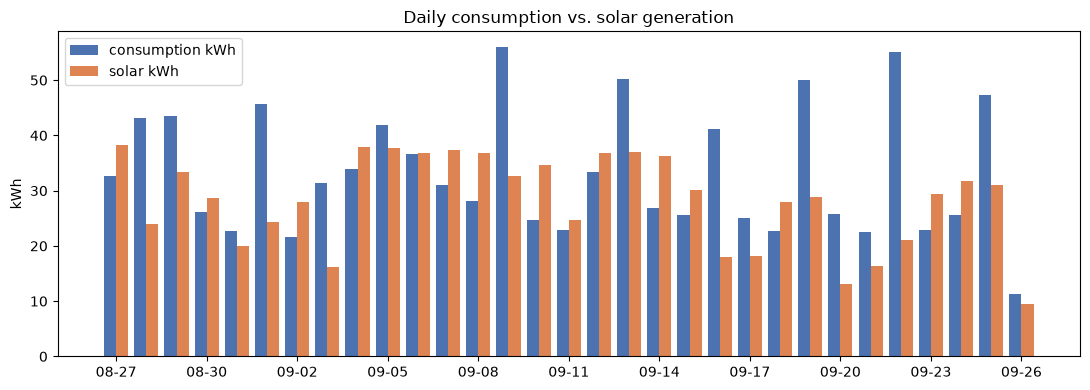

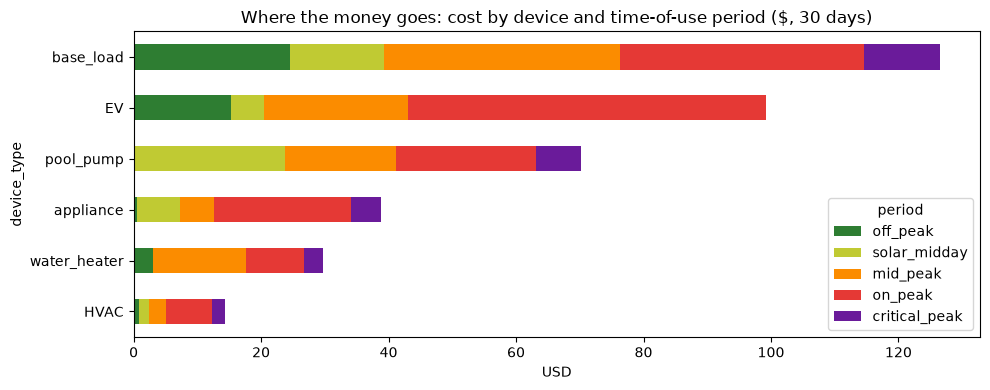

Share of each device's cost incurred on-peak (%):
device_type
appliance       67.3
HVAC            64.4
EV              56.6
pool_pump       41.5
water_heater    40.9
base_load       39.7


In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(daily))
ax.bar([i - 0.2 for i in x], daily.consumption_kwh, width=0.4, label="consumption kWh", color="#4c72b0")
ax.bar([i + 0.2 for i in x], daily.solar_kwh, width=0.4, label="solar kWh", color="#dd8452")
ax.set_xticks(list(x)[::3]); ax.set_xticklabels([str(d)[5:] for d in daily.index][::3])
ax.set(title="Daily consumption vs. solar generation", ylabel="kWh"); ax.legend()
fig.tight_layout(); fig.savefig(figdir / "01_daily_balance.png", dpi=110); plt.show()

period_cost = usage_df.pivot_table(index="device_type", columns="period", values="cost_usd", aggfunc="sum").fillna(0)
period_cost = period_cost.loc[period_cost.sum(axis=1).sort_values().index]
order = [p for p in ["off_peak", "solar_midday", "mid_peak", "on_peak", "critical_peak"] if p in period_cost]
period_colours = {"off_peak": "#2e7d32", "solar_midday": "#c0ca33", "mid_peak": "#fb8c00",
                  "on_peak": "#e53935", "critical_peak": "#6a1b9a"}
ax = period_cost[order].plot(kind="barh", stacked=True, figsize=(10, 4), color=[period_colours[p] for p in order],
                      title="Where the money goes: cost by device and time-of-use period ($, 30 days)")
ax.set_xlabel("USD"); plt.tight_layout(); plt.savefig(figdir / "01_cost_by_period.png", dpi=110); plt.show()

peak_share = (usage_df[usage_df.period.isin(["on_peak", "critical_peak"])].groupby("device_type")["cost_usd"].sum()
              / usage_df.groupby("device_type")["cost_usd"].sum() * 100).round(1).sort_values(ascending=False)
print("Share of each device's cost incurred on-peak (%):")
print(peak_share.to_string())

## 7. Test Database Tools

In [11]:
# Test the database query functions from tools.py
# Import and test: query_energy_usage, query_solar_generation, get_recent_energy_summary

from tools import query_energy_usage, query_solar_generation, get_recent_energy_summary, analyze_usage_patterns

# Test querying data for the last 7 days
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%d")

print("=== Testing Database Tools ===")
print(f"Querying data from {start_date} to {end_date}")

# Test energy usage query
usage_data = query_energy_usage.invoke(
    input={
        "start_date": start_date,
        "end_date": end_date,
    }
)
print(f"\nEnergy Usage Query Results:")
print(f"  Total records: {usage_data['total_records']}")
print(f"  Total consumption: {usage_data['total_consumption_kwh']} kWh")
print(f"  Total cost: ${usage_data['total_cost_usd']}")
print(f"  By device type: { {k: v['consumption_kwh'] for k, v in usage_data['by_device_type'].items()} }")

# Test solar generation query
generation_data = query_solar_generation.invoke(
    input={
        "start_date": start_date,
        "end_date": end_date,
    }
)
print(f"\nSolar Generation Query Results:")
print(f"  Total records: {generation_data['total_records']}")
print(f"  Total generation: {generation_data['total_generation_kwh']} kWh")
print(f"  Average daily: {generation_data['average_daily_generation']} kWh")
print(f"  Best day: {generation_data['best_day']}")

# Test recent energy summary
summary = get_recent_energy_summary.invoke(
    input={
        "hours": 24
    }
)
print(f"\nRecent Energy Summary:")
print(f"  Usage: {summary['usage']['total_consumption_kwh']} kWh, ${summary['usage']['total_cost_usd']}")
print(f"  Generation: {summary['generation']['total_generation_kwh']} kWh")
print(f"  Weather: {summary['generation']['average_weather']}")
print(f"  Balance: {summary['balance']}")

# Device filter using a device *name* (starter only matched exact device_type strings)
dish = query_energy_usage.invoke({"start_date": start_date, "end_date": end_date, "device_type": "dishwasher"})
print(f"\nDishwasher only: {dish['total_consumption_kwh']} kWh, ${dish['total_cost_usd']}")

=== Testing Database Tools ===
Querying data from 2026-09-19 to 2026-09-26

Energy Usage Query Results:
  Total records: 308
  Total consumption: 260.31 kWh
  Total cost: $101.25
  By device type: {'base_load': 89.01, 'water_heater': 18.54, 'appliance': 25.18, 'pool_pump': 46.06, 'EV': 77.72, 'HVAC': 3.8}

Solar Generation Query Results:
  Total records: 89
  Total generation: 180.84 kWh
  Average daily: 22.61 kWh
  Best day: {'date': '2026-09-24', 'generation_kwh': 31.7, 'condition': 'sunny'}

Recent Energy Summary:
  Usage: 52.87 kWh, $22.78
  Generation: 30.33 kWh
  Weather: sunny
  Balance: {'net_grid_kwh': 22.54, 'solar_self_consumed_kwh': 15.3, 'solar_exported_kwh': 15.03, 'grid_imported_kwh': 37.57, 'self_sufficiency_pct': 28.9, 'solar_self_consumption_pct': 50.4}

Dishwasher only: 8.34 kWh, $3.5


In [12]:
# The added analysis tool: ranked, data-driven savings opportunities from this household's own history
patterns = analyze_usage_patterns.invoke({"days": 30})
print(f"Projected monthly bill (gross): ${patterns['projected_monthly_bill_usd']}")
print(f"Solar self-consumption: {patterns['solar']['self_consumption_pct']}% "
      f"({patterns['solar']['exported_kwh']} kWh exported for ${patterns['solar']['export_value_usd']})")
pd.DataFrame(patterns["top_opportunities"])[["device_type", "estimated_monthly_savings_usd",
                                            "estimated_annual_savings_usd", "action"]]

Projected monthly bill (gross): $377.44
Solar self-consumption: 47.2% (455.2 kWh exported for $22.76)


,device_type,estimated_monthly_savings_usd,estimated_annual_savings_usd,action
0,solar,43.24,526.15,Soak up exported midday solar with flexible lo...
1,EV,41.20,494.41,Schedule EV charging to start after 22:00 (or ...
2,pool_pump,22.71,272.50,Move the pool pump to 09:00-15:00 so it runs o...
3,appliance,18.67,224.08,Delay-start the dishwasher and laundry to afte...
4,water_heater,12.85,154.25,Pre-heat the heat-pump water heater midday and...


## Summary

- `energy_data.db` holds the two required tables (`energy_usage` for **EnergyUsage**, `solar_generation` for
  **SolarGeneration**) plus `user_preferences`.
- The history is realistic in magnitude and deliberately un-optimised, so tools such as `analyze_usage_patterns`
  and `optimize_device_schedule` find genuine savings, and costs agree with the pricing tool to the cent.
- Next: `02_rag_setup.ipynb` builds the knowledge base.